# Business Analytics Project 2 — Final Project

## Generative AI Declaration

Generative AI was used for code debugging, Python learning support and proofreading,

## ETF Fund Flows, Flow-Performance Sensitivity, Clustering, and Market Beta Analysis

This notebook analyses US ETF fund flows for IRESS clients, including fund managers and financial advisors. The analysis follows the final project brief and applies Python-based business analytics methods covered in Seminars 4, 5, and 6.

The notebook is structured as follows:

1. Data preparation and cleaning  
2. Flow-performance regressions  
3. Predictive modelling with and without seasonality  
4. Logistic regression for positive versus negative flows  
5. ETF clustering using flow-performance sensitivity  
6. ETF return sensitivity to S&P 500 returns  

## 1.0 Data Preparation


The key choices are as follows:

- `PERMNO` is used as the main ETF identifier because it is a permanent security identifier.

- `TICKER` and `COMNAM` are retained only for display and interpretation.

- Negative CRSP prices are converted using `abs(PRC)` because negative prices indicate bid/ask average flags, not true negative prices.
  
- AUM is calculated as `abs(PRC) × SHROUT`.
  
- ETF net flow is calculated as the monthly change in AUM, following the assignment definition of flows as the monthly change in `SHROUT × PRC`.
  
- Lagged variables are created within each `PERMNO` to avoid mixing observations across ETFs.


In [1]:
# 1.1 Import necessary libraries

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
# 1.2 Load the datasets

etf = pd.read_csv("US_data_ETFs.csv")
sp500 = pd.read_csv("US_data_sp500.csv")

print("ETF data shape:", etf.shape)
print("S&P 500 data shape:", sp500.shape)

display(etf.head())
display(sp500.head())

ETF data shape: (386955, 10)
S&P 500 data shape: (300, 2)


,PERMNO,date,SHRCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT
0,10113,2010-07-30,73,AADR,ADVISORSHARES TRUST,53202,25.1000,"1,018.0000",C,100.0000
1,10113,2010-08-31,73,AADR,ADVISORSHARES TRUST,53202,25.3450,624.0000,0.009761,100.0000
2,10113,2010-09-30,73,AADR,ADVISORSHARES TRUST,53202,28.2100,"1,912.0000",0.113040,225.0000
3,10113,2010-10-29,73,AADR,ADVISORSHARES TRUST,53202,28.8593,"1,233.0000",0.023017,275.0000
4,10113,2010-11-30,73,AADR,ADVISORSHARES TRUST,53202,28.3000,268.0000,-0.019380,275.0000


,date,sprtrn
0,31/01/2000,-0.0509
1,29/02/2000,-0.0201
2,31/03/2000,0.0967
3,28/04/2000,-0.0308
4,31/05/2000,-0.0219


In [3]:
#1.3 Parse dates and inspect columns
##The ETF file uses `YYYY-MM-DD`, while the S&P 500 file uses `DD/MM/YYYY`. Both are converted into datetime format before merging.

etf["date"] = pd.to_datetime(etf["date"], errors="coerce")
sp500["date"] = pd.to_datetime(sp500["date"], format="%d/%m/%Y", errors="coerce")

print("ETF date range:", etf["date"].min(), "to", etf["date"].max())
print("S&P 500 date range:", sp500["date"].min(), "to", sp500["date"].max())

print("\nETF columns:")
print(etf.columns.tolist())

print("\nS&P 500 columns:")
print(sp500.columns.tolist())

ETF date range: 2000-01-31 00:00:00 to 2024-12-31 00:00:00
S&P 500 date range: 2000-01-31 00:00:00 to 2024-12-31 00:00:00

ETF columns:
['PERMNO', 'date', 'SHRCD', 'TICKER', 'COMNAM', 'PERMCO', 'PRC', 'VOL', 'RET', 'SHROUT']

S&P 500 columns:
['date', 'sprtrn']


The ETF and S&P 500 datasets cover the same monthly period, which allows the two datasets to be merged by date. This is necessary because Q3 requires ETF returns to be regressed on S&P 500 returns.

In [4]:
# 1.4 Initial data quality checks
print("Unique SHRCD values:")
display(etf["SHRCD"].value_counts(dropna=False))

duplicate_permno_date = etf.duplicated(subset=["PERMNO", "date"]).sum()
print("\nDuplicate PERMNO-date rows:", duplicate_permno_date)

print("\nUnique PERMNO:", etf["PERMNO"].nunique())
print("Unique TICKER:", etf["TICKER"].nunique())

print("\nMissing values by column:")
display(etf.isna().sum())

Unique SHRCD values:


SHRCD
73    386955
Name: count, dtype: int64


Duplicate PERMNO-date rows: 0

Unique PERMNO: 5688
Unique TICKER: 5739

Missing values by column:


PERMNO       0
date         0
SHRCD        0
TICKER       0
COMNAM       0
PERMCO       0
PRC       1936
VOL        172
RET       1936
SHROUT     172
dtype: int64

In [5]:
# 1.5 Clean ETF returns and prices
## The return variable is converted to numeric format
## Non-numeric CRSP return values such as "C" are converted to missing.
## Negative CRSP prices are converted using "abs(PRC) because negative price indicate bid/ask average flags but not actual negative prices

etf["RET_raw"] = etf["RET"]
etf["RET"] = pd.to_numeric(etf["RET"], errors="coerce")

missing_return_codes = [-66, -77, -88, -99]
etf.loc[etf["RET"].isin(missing_return_codes), "RET"] = np.nan

etf["PRC_raw"] = etf["PRC"]
etf["PRC"] = etf["PRC"].abs()

print("Missing RET after cleaning:", etf["RET"].isna().sum())
print("Negative PRC rows before abs():", (etf["PRC_raw"] < 0).sum())

display(etf[[
    "PERMNO", "TICKER", "date", "PRC_raw", "PRC",
    "RET_raw", "RET", "SHROUT"
]].head(10))

Missing RET after cleaning: 7592
Negative PRC rows before abs(): 19628


,PERMNO,TICKER,date,PRC_raw,PRC,RET_raw,RET,SHROUT
0,10113,AADR,2010-07-30,25.1000,25.1000,C,NaN,100.0000
1,10113,AADR,2010-08-31,25.3450,25.3450,0.009761,0.0098,100.0000
2,10113,AADR,2010-09-30,28.2100,28.2100,0.113040,0.1130,225.0000
3,10113,AADR,2010-10-29,28.8593,28.8593,0.023017,0.0230,275.0000
4,10113,AADR,2010-11-30,28.3000,28.3000,-0.019380,-0.0194,275.0000
5,10113,AADR,2010-12-31,29.8400,29.8400,0.056872,0.0569,275.0000
6,10113,AADR,2011-01-31,29.8360,29.8360,-0.000134,-0.0001,275.0000
7,10113,AADR,2011-02-28,30.5000,30.5000,0.022255,0.0223,275.0000
8,10113,AADR,2011-03-31,-30.5450,30.5450,0.001475,0.0015,275.0000
9,10113,AADR,2011-04-29,31.9900,31.9900,0.047307,0.0473,275.0000


- The `RET` variable is converted to numeric because regression models require numeric input.

- Non-numeric CRSP return codes such as `C` are treated as missing values and removed from modelling where required.

In [6]:
# 1.6 Sort observations and check monthly continuity

## Before creating flows and lags, the data is sorted by "PERMNO" and date.

## A monthtly index is created to ensure lagged variables are

etf = etf.sort_values(["PERMNO", "date"]).reset_index(drop=True)

etf["month_index"] = etf["date"].dt.year * 12 + etf["date"].dt.month
etf["prev_month_index"] = etf.groupby("PERMNO")["month_index"].shift(1)
etf["month_gap"] = etf["month_index"] - etf["prev_month_index"]

print("Month gap counts:")
display(etf["month_gap"].value_counts(dropna=False).head(10))

Month gap counts:


month_gap
1.0000     381246
NaN          5688
2.0000         14
3.0000          3
10.0000         2
9.0000          1
4.0000          1
Name: count, dtype: int64

In [7]:
# 1.7 Construct AUM and ETF net flows

# AUM is in thousand USD because SHROUT is measured in thousands of shares.
etf["AUM_thousand_usd"] = etf["PRC"] * etf["SHROUT"]
etf["AUM_mln"] = etf["AUM_thousand_usd"] / 1000

# Monthly change in SHROUT × PRC.
etf["net_flow_thousand_usd"] = etf.groupby("PERMNO")["AUM_thousand_usd"].diff()
etf["net_flow_mln"] = etf["net_flow_thousand_usd"] / 1000

# Remove flow values where the previous observation is not the previous month.
etf.loc[etf["month_gap"] != 1, ["net_flow_thousand_usd", "net_flow_mln"]] = np.nan

# Alternative flow measure for robustness only: change in SHROUT × current price.
etf["delta_SHROUT"] = etf.groupby("PERMNO")["SHROUT"].diff()
etf["alt_flow_creation_thousand_usd"] = etf["delta_SHROUT"] * etf["PRC"]
etf["alt_flow_creation_mln"] = etf["alt_flow_creation_thousand_usd"] / 1000

etf.loc[
    etf["month_gap"] != 1,
    ["delta_SHROUT", "alt_flow_creation_thousand_usd", "alt_flow_creation_mln"]
] = np.nan

display(etf[[
    "PERMNO", "TICKER", "date", "PRC", "SHROUT",
    "AUM_mln", "net_flow_mln", "alt_flow_creation_mln"
]].head(12))

,PERMNO,TICKER,date,PRC,SHROUT,AUM_mln,net_flow_mln,alt_flow_creation_mln
0,10113,AADR,2010-07-30,25.1000,100.0000,2.5100,NaN,NaN
1,10113,AADR,2010-08-31,25.3450,100.0000,2.5345,0.0245,0.0000
2,10113,AADR,2010-09-30,28.2100,225.0000,6.3472,3.8127,3.5263
3,10113,AADR,2010-10-29,28.8593,275.0000,7.9363,1.5891,1.4430
4,10113,AADR,2010-11-30,28.3000,275.0000,7.7825,-0.1538,0.0000
5,10113,AADR,2010-12-31,29.8400,275.0000,8.2060,0.4235,0.0000
6,10113,AADR,2011-01-31,29.8360,275.0000,8.2049,-0.0011,0.0000
7,10113,AADR,2011-02-28,30.5000,275.0000,8.3875,0.1826,0.0000
8,10113,AADR,2011-03-31,30.5450,275.0000,8.3999,0.0124,0.0000
9,10113,AADR,2011-04-29,31.9900,275.0000,8.7973,0.3974,0.0000


In [8]:
# 1.8 Create lagged variables

#The key explanatory variable is `lag_1`, which represents the previous month’s ETF return. This naming follows the style of Seminar 5, but the meaning is adjusted to match the assignment definition of flow-performance sensitivity.

#Additional return lags, lagged flow, and lagged AUM are also created for extended regression models.

# Create lagged variables within each ETF using PERMNO
etf["lag_1"] = etf.groupby("PERMNO")["RET"].shift(1)

# Additional return lags for extended regression models
etf["lag_ret_2"] = etf.groupby("PERMNO")["RET"].shift(2)
etf["lag_ret_3"] = etf.groupby("PERMNO")["RET"].shift(3)

# Lagged flow and lagged AUM as control variables
etf["lag_flow_1"] = etf.groupby("PERMNO")["net_flow_mln"].shift(1)
etf["lag_AUM_mln"] = etf.groupby("PERMNO")["AUM_mln"].shift(1)

# Month and year variables for seasonality and annual beta analysis
etf["month"] = etf["date"].dt.month
etf["year"] = etf["date"].dt.year

display(etf[[
    "PERMNO", "TICKER", "date", "RET", "net_flow_mln",
    "lag_1", "lag_ret_2", "lag_ret_3",
    "lag_flow_1", "lag_AUM_mln", "month", "year"
]].head(15))

,PERMNO,TICKER,date,RET,net_flow_mln,lag_1,lag_ret_2,lag_ret_3,lag_flow_1,lag_AUM_mln,month,year
0,10113,AADR,2010-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2010
1,10113,AADR,2010-08-31,0.0098,0.0245,NaN,NaN,NaN,NaN,2.5100,8,2010
2,10113,AADR,2010-09-30,0.1130,3.8127,0.0098,NaN,NaN,0.0245,2.5345,9,2010
3,10113,AADR,2010-10-29,0.0230,1.5891,0.1130,0.0098,NaN,3.8127,6.3472,10,2010
4,10113,AADR,2010-11-30,-0.0194,-0.1538,0.0230,0.1130,0.0098,1.5891,7.9363,11,2010
5,10113,AADR,2010-12-31,0.0569,0.4235,-0.0194,0.0230,0.1130,-0.1538,7.7825,12,2010
6,10113,AADR,2011-01-31,-0.0001,-0.0011,0.0569,-0.0194,0.0230,0.4235,8.2060,1,2011
7,10113,AADR,2011-02-28,0.0223,0.1826,-0.0001,0.0569,-0.0194,-0.0011,8.2049,2,2011
8,10113,AADR,2011-03-31,0.0015,0.0124,0.0223,-0.0001,0.0569,0.1826,8.3875,3,2011
9,10113,AADR,2011-04-29,0.0473,0.3974,0.0015,0.0223,-0.0001,0.0124,8.3999,4,2011


In [9]:
# 1.9 Create winsorised flow variable for robustness

# The main dependent variable is "net_flow_min"

# A winsorized version of net_flow_min is created only for robustness checks. In case extreme ETF flows strongly affect the regression results.

# Create winsorised net flow for robustness checks only

flow_lower = etf["net_flow_mln"].quantile(0.01)
flow_upper = etf["net_flow_mln"].quantile(0.99)

etf["net_flow_winz_mln"] = etf["net_flow_mln"].clip(
    lower=flow_lower,
    upper=flow_upper
)

print("Net flow 1st percentile:", flow_lower)
print("Net flow 99th percentile:", flow_upper)

display(etf[["net_flow_mln", "net_flow_winz_mln"]].describe())


Net flow 1st percentile: -671.5148
Net flow 99th percentile: 1114.2571734000012


,net_flow_mln,net_flow_winz_mln
count,"379,331.0000","379,331.0000"
mean,26.5658,19.7758
std,661.2055,175.5748
min,"-45,792.7477",-671.5148
25%,-2.1063,-2.1063
50%,0.2888,0.2888
75%,10.1043,10.1043
max,"58,828.2816","1,114.2572"


In [10]:
# 1.10 Classify ETF's by fund type

def classify_fund_type(name):
    if pd.isna(name):
        return "Other"

    text = str(name).upper()

    if (
        "LEVERAGED" in text or "INVERSE" in text or "BEAR" in text or
        "BULL" in text or "ULTRA" in text or "2X" in text or "3X" in text
    ):
        return "Leveraged/Inverse"

    elif (
        "BOND" in text or "TREASURY" in text or "FIXED INCOME" in text or
        "MUNICIPAL" in text or "MUNI" in text or "YIELD" in text or
        "CREDIT" in text or "INCOME" in text or "DEBT" in text or
        "CORPORATE" in text or "GOVERNMENT" in text
    ):
        return "Bond/Fixed Income"

    elif (
        "GOLD" in text or "SILVER" in text or "OIL" in text or
        "COMMODITY" in text or "COMMODITIES" in text or "METALS" in text or
        "NATURAL GAS" in text or "CRUDE" in text
    ):
        return "Commodity"

    elif (
        "INTERNATIONAL" in text or "GLOBAL" in text or "EMERGING" in text or
        "FOREIGN" in text or "EAFE" in text or "EUROPE" in text or
        "ASIA" in text or "CHINA" in text or "JAPAN" in text or
        "LATIN" in text or "DEVELOPED" in text or "EX-US" in text or
        "EX US" in text or "WORLD" in text
    ):
        return "International/EM"

    elif (
        "TECHNOLOGY" in text or "TECH" in text or "FINANCIAL" in text or
        "HEALTH" in text or "ENERGY" in text or "UTILITIES" in text or
        "REAL ESTATE" in text or "REIT" in text or "CONSUMER" in text or
        "INDUSTRIAL" in text or "MATERIALS" in text or
        "COMMUNICATION" in text or "SEMICONDUCTOR" in text or
        "BIOTECH" in text or "BANK" in text
    ):
        return "Sector Equity"

    elif (
        "S&P" in text or "SPDR" in text or "RUSSELL" in text or
        "NASDAQ" in text or "DOW" in text or "TOTAL MARKET" in text or
        "EQUITY" in text or "GROWTH" in text or "VALUE" in text or
        "DIVIDEND" in text or "LARGE CAP" in text or "MID CAP" in text or
        "SMALL CAP" in text or "INDEX" in text or "MARKET" in text or
        "ISHARES" in text or "VANGUARD" in text or "WISDOMTREE" in text
    ):
        return "Broad Equity"

    else:
        return "Other"


etf["fund_type"] = etf["COMNAM"].apply(classify_fund_type)

fund_type_counts = (
    etf.groupby("fund_type")["PERMNO"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("unique_etfs")
)

display(fund_type_counts)

,unique_etfs
fund_type,
Other,4238
Broad Equity,1220
International/EM,241
Commodity,70
Bond/Fixed Income,36
Sector Equity,26
Leveraged/Inverse,1


In [11]:
# 1.11 Merge S&P 500 returns

# The S&P 500 return data is merged with the ETF data using monthly date.

# Convert S&P 500 return to numeric
sp500["sprtrn"] = pd.to_numeric(sp500["sprtrn"], errors="coerce")

# Merge ETF data with S&P 500 returns by date
panel_full = pd.merge(
    etf,
    sp500[["date", "sprtrn"]],
    on="date",
    how="left"
)

print("Panel shape after merge:", panel_full.shape)
print("Missing S&P 500 returns:", panel_full["sprtrn"].isna().sum())

display(panel_full[[
    "PERMNO", "TICKER", "date", "RET", "sprtrn",
    "AUM_mln", "net_flow_mln", "lag_1", "fund_type"
]].head())

Panel shape after merge: (386955, 32)
Missing S&P 500 returns: 0


,PERMNO,TICKER,date,RET,sprtrn,AUM_mln,net_flow_mln,lag_1,fund_type
0,10113,AADR,2010-07-30,NaN,0.0688,2.5100,NaN,NaN,Other
1,10113,AADR,2010-08-31,0.0098,-0.0474,2.5345,0.0245,NaN,Other
2,10113,AADR,2010-09-30,0.1130,0.0876,6.3472,3.8127,0.0098,Other
3,10113,AADR,2010-10-29,0.0230,0.0369,7.9363,1.5891,0.1130,Other
4,10113,AADR,2010-11-30,-0.0194,-0.0023,7.7825,-0.1538,0.0230,Other


In [12]:
# 1.12 Apply minimum observation filter

# Prior running regressions, ETFs with too few valid observations are removed

# The applied filter retains ETF's with at least 36 valid observations for "net_flow_min and "lag_1"

# Count valid observations for each ETF
valid_counts = (
    panel_full
    .dropna(subset=["net_flow_mln", "lag_1"])
    .groupby("PERMNO")
    .size()
)

# Keep ETFs with at least 36 valid observations
MIN_OBS = 36
eligible_permnos = valid_counts[valid_counts >= MIN_OBS].index

# Create final analytical panel
panel = panel_full[panel_full["PERMNO"].isin(eligible_permnos)].copy()

print("Eligible ETFs:", len(eligible_permnos))
print("Final panel shape:", panel.shape)

display(panel[[
    "PERMNO", "TICKER", "COMNAM", "date", "fund_type",
    "RET", "sprtrn", "AUM_mln", "net_flow_mln",
    "lag_1", "lag_flow_1", "lag_AUM_mln"
]].head())

Eligible ETFs: 3023
Final panel shape: (340945, 32)


,PERMNO,TICKER,COMNAM,date,fund_type,RET,sprtrn,AUM_mln,net_flow_mln,lag_1,lag_flow_1,lag_AUM_mln
0,10113,AADR,ADVISORSHARES TRUST,2010-07-30,Other,NaN,0.0688,2.5100,NaN,NaN,NaN,NaN
1,10113,AADR,ADVISORSHARES TRUST,2010-08-31,Other,0.0098,-0.0474,2.5345,0.0245,NaN,NaN,2.5100
2,10113,AADR,ADVISORSHARES TRUST,2010-09-30,Other,0.1130,0.0876,6.3472,3.8127,0.0098,0.0245,2.5345
3,10113,AADR,ADVISORSHARES TRUST,2010-10-29,Other,0.0230,0.0369,7.9363,1.5891,0.1130,3.8127,6.3472
4,10113,AADR,ADVISORSHARES TRUST,2010-11-30,Other,-0.0194,-0.0023,7.7825,-0.1538,0.0230,1.5891,7.9363


The final analytical panel keeps ETFs with sufficient valid observations for regression analysis. This improves model stability and avoids estimating ETF-level regressions using very short time series.

## 2.0 - Q1A: Flow-Performance Sensitivity Regression

This section estimates whether ETF flows respond to past ETF returns

### Main Regression Specification

- The main regression specification is:

\[
NetFlow_{i,t} = \alpha + \beta Ret_{i,t-1} + \varepsilon_{i,t}
\]

- where \(NetFlow_{i,t}\) is ETF \(i\)'s net flow in month \(t\), measured in millions of dollars, \(Ret_{i,t-1}\) is the ETF's return in the previous month, and \(\beta\) is the flow-performance sensitivity. 

- Models 2–5 extend this baseline by adding lagged flow, additional return lags, lagged AUM, and month dummies.

In [13]:
# 2.1 Select one ETF for the regression sample

# SPY is selected as it is one of the most recognizable ETF's and has a long trading history.

spy = panel[panel["TICKER"] == "SPY"]

spy.head()

,PERMNO,date,SHRCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RET_raw,PRC_raw,month_index,prev_month_index,month_gap,AUM_thousand_usd,AUM_mln,net_flow_thousand_usd,net_flow_mln,delta_SHROUT,alt_flow_creation_thousand_usd,alt_flow_creation_mln,lag_1,lag_ret_2,lag_ret_3,lag_flow_1,lag_AUM_mln,month,year,net_flow_winz_mln,fund_type,sprtrn
225085,84398,2000-01-31,73,SPY,SPDR TRUST,46699,139.6250,"1,566,969.0000",-0.0494,"27,109.0000",-0.049362,139.6250,24001,NaN,NaN,"3,785,094.1250","3,785.0941",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2000,NaN,Broad Equity,-0.0509
225086,84398,2000-02-29,73,SPY,SPDR TRUST,46699,137.4375,"1,871,794.0000",-0.0157,"102,670.0000",-0.015667,137.4375,24002,"24,001.0000",1.0000,"14,110,708.1250","14,110.7081","10,325,614.0000","10,325.6140","75,561.0000","10,384,914.9375","10,384.9149",-0.0494,NaN,NaN,NaN,"3,785.0941",2,2000,"1,114.2572",Broad Equity,-0.0201
225087,84398,2000-03-31,73,SPY,SPDR TRUST,46699,150.3750,"2,475,911.0000",0.0968,"102,670.0000",0.096832,150.3750,24003,"24,002.0000",1.0000,"15,439,001.2500","15,439.0012","1,328,293.1250","1,328.2931",0.0000,0.0000,0.0000,-0.0157,-0.0494,NaN,"10,325.6140","14,110.7081",3,2000,"1,114.2572",Broad Equity,0.0967
225088,84398,2000-04-28,73,SPY,SPDR TRUST,46699,145.0938,"2,304,456.0000",-0.0351,"102,670.0000",-0.035121,145.0938,24004,"24,003.0000",1.0000,"14,896,775.3125","14,896.7753","-542,225.9375",-542.2259,0.0000,0.0000,0.0000,0.0968,-0.0157,-0.0494,"1,328.2931","15,439.0012",4,2000,-542.2259,Broad Equity,-0.0308
225089,84398,2000-05-31,73,SPY,SPDR TRUST,46699,142.8125,"1,605,756.0000",-0.0157,"102,670.0000",-0.015723,142.8125,24005,"24,004.0000",1.0000,"14,662,559.3750","14,662.5594","-234,215.9375",-234.2159,0.0000,0.0000,0.0000,-0.0351,0.0968,-0.0157,-542.2259,"14,896.7753",5,2000,-234.2159,Broad Equity,-0.0219


In [14]:
# 2.2 Model 1: Univariate OLS regression

# This is the main flow-performance sensitivity regression

model1 = smf.ols("net_flow_mln ~ lag_1", data=spy).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:           net_flow_mln   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.970
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.161
Time:                        23:09:21   Log-Likelihood:                -3264.2
No. Observations:                 299   AIC:                             6532.
Df Residuals:                     297   BIC:                             6540.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2237.0256    784.153      2.853      0.0

In [15]:
# 2.3 Model 2: Add lagged flow

# This model adds last month's ETF flow as a control variable

model2 = smf.ols("net_flow_mln ~ lag_1 + lag_flow_1", data=spy).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           net_flow_mln   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     6.007
Date:                Mon, 01 Jun 2026   Prob (F-statistic):            0.00277
Time:                        23:09:21   Log-Likelihood:                -3248.7
No. Observations:                 298   AIC:                             6503.
Df Residuals:                     295   BIC:                             6514.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2367.6161    776.781      3.048      0.0

In [16]:
# 2.4 Model 3: Add extra lagged returns

model3 = smf.ols("net_flow_mln ~ lag_1 + lag_ret_2 + lag_ret_3", data=spy).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:           net_flow_mln   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.852
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.138
Time:                        23:09:21   Log-Likelihood:                -3241.4
No. Observations:                 297   AIC:                             6491.
Df Residuals:                     293   BIC:                             6506.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2230.6646    808.685      2.758      0.0

In [17]:
# 2.5 Model 4: Add lagged flow and lagged AUM

model4 = smf.ols("net_flow_mln ~ lag_1 + lag_flow_1 + lag_AUM_mln", data=spy).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:           net_flow_mln   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     6.665
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           0.000228
Time:                        23:09:21   Log-Likelihood:                -3244.8
No. Observations:                 298   AIC:                             6498.
Df Residuals:                     294   BIC:                             6512.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -125.9643   1181.831     -0.107      

In [18]:
# 2.6 Model 5: Add month dummies

model5 = smf.ols("net_flow_mln ~ lag_1 + lag_flow_1 + lag_AUM_mln + C(month)", data=spy).fit()

print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:           net_flow_mln   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     4.150
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.32e-06
Time:                        23:09:21   Log-Likelihood:                -3226.8
No. Observations:                 298   AIC:                             6484.
Df Residuals:                     283   BIC:                             6539.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -3295.6375   2749.027     -1.

In [19]:
# 2.7 Regression comparison table — stacked format 

table = summary_col(
    [model1, model2, model3, model4, model5],
    model_names=["(1)", "(2)", "(3)", "(4)", "(5)"],
    stars=True,
    float_format="%.3f",
    regressor_order=["Intercept", "lag_1", "lag_flow_1", "lag_ret_2", "lag_ret_3", "lag_AUM_mln"],
    drop_omitted=True,
    info_dict={
        "Month FE":     lambda x: "Yes" if any("C(month)" in p for p in x.params.index) else "No",
        "Observations": lambda x: f"{int(x.nobs)}",
    },
)

models = [model1, model2, model3, model4, model5]
tbl = table.tables[0].copy()

for col_idx, m in enumerate(models, start=1):
    tvals = m.tvalues
    # Every other row (the parenthesised rows) sits one row below the coefficient row
    for var in tvals.index:
        if var in tbl.index:
            row_pos = tbl.index.get_loc(var)
            tbl.iloc[row_pos + 1, col_idx - 1] = f"({tvals[var]:.3f})"
            
print("Dependent variable: ETF net flow ($ millions)")
print("=" * 80)
print(tbl.to_string())
print("\nt-statistics in parentheses.")
print("* p < .1, ** p < .05, *** p < .01")

Dependent variable: ETF net flow ($ millions)
                        (1)          (2)          (3)        (4)        (5)
Intercept       2237.026***  2367.616***  2230.665***   -125.964  -3295.637
                    (2.853)      (3.048)      (2.758)   (-0.107)   (-1.199)
lag_1            -24675.426    20629.755   -22041.772  20645.007  20255.613
                   (-1.404)      (0.923)     (-1.246)    (0.934)    (0.918)
lag_flow_1                     -0.233***               -0.268***  -0.305***
                                (-3.179)                (-3.637)   (-4.049)
lag_ret_2                                  -26173.306                      
                                             (-1.481)                      
lag_ret_3                                   22147.785                      
                                              (1.253)                      
lag_AUM_mln                                             0.015***   0.016***
                                          

- The table reports five OLS regression specifications for SPY. Model 1 is the baseline flow-performance model using only lagged ETF return. Models 2–5 add lagged flow, additional return lags, lagged AUM, and month fixed effects.

- The coefficient on `lag_1` is not statistically significant across the five models, suggesting that SPY flows are not strongly explained by past monthly returns alone. In contrast, `lag_flow_1` is negative and statistically significant in the models where it is included, indicating some reversal in monthly flows. The R-squared increases from 0.007 in Model 1 to 0.170 in Model 5, showing that adding lagged flow, AUM, and month effects improves explanatory power, although the overall fit remains modest.

# Q1b: Predicting ETF Flows Without Seasonality

This section uses the main flow-performance regression to predict ETF net flows

In [20]:
# 2.8 Select 20 ETF's for prediction

# Count valid observations for each ETF in the cleaned panel.

# Using stricter 60-observation filter because prediction needs a stable train/test split.


valid_counts_60 = (
    panel
    .dropna(subset=["net_flow_mln", "lag_1"])
    .groupby("PERMNO")
    .size()
)

# Keep ETFs with at least 60 valid observations for prediction.
eligible_60 = valid_counts_60[valid_counts_60 >= 60].index

# Select the first 20 eligible ETFs for the assignment requirement.
# This keeps the code simple and close to the seminar style.
selected_etfs = eligible_60[:20]

# Create the prediction sample containing only these 20 ETFs.
prediction_sample = panel[panel["PERMNO"].isin(selected_etfs)]

print("ETFs available with at least 60 valid observations:", len(eligible_60))
print("Number of selected ETFs:", prediction_sample["PERMNO"].nunique())

prediction_sample[["PERMNO", "TICKER", "COMNAM"]].drop_duplicates().head(20)


ETFs available with at least 60 valid observations: 2127
Number of selected ETFs: 20


,PERMNO,TICKER,COMNAM
0,10113,AADR,ADVISORSHARES TRUST
287,11182,FCGL,DIREXION SHARES E T F TRUST
297,11182,GASL,DIREXION SHARES E T F TRUST
431,11264,RETL,DIREXION SHARES E T F TRUST
605,11363,SCIN,E G A EMERGING GLOBAL SHARES TR
680,11363,SCIN,COLUMBIA E T F TRUST II
713,11407,LIT,GLOBAL X FUNDS
887,11505,BRAF,GLOBAL X FUNDS
951,11648,BRAQ,GLOBAL X FUNDS
1444,11996,EMLC,MARKET VECTORS E T F TRUST


In [21]:
# 2.9 Example of train-test split for one ETF

# Before repeating the process for 20 ETFs, the train-test split is shown for one ETF

# Select the first ETF from the 20 selected ETFs.
one_etf = prediction_sample[prediction_sample["PERMNO"] == selected_etfs[0]]

# Keep only the variables needed for the prediction model.
# Drop missing values because OLS cannot use rows with missing y or x values.
one_etf = one_etf[["date", "net_flow_mln", "lag_1"]].dropna()

# Sort by date so the first 80% is the earlier period and the last 20% is the later period.
# This is important because this is time-series style ETF data.
one_etf = one_etf.sort_values("date")

# Create the 80/20 split.
split = int(len(one_etf) * 0.8)

train = one_etf.iloc[:split]
test = one_etf.iloc[split:]

print("Total observations:", len(one_etf))
print("Training observations:", len(train))
print("Testing observations:", len(test))

Total observations: 172
Training observations: 137
Testing observations: 35


In [22]:
# 2.10 Estimate OLS on the training sample

# Estimate the same main regression used in Q1a.
model = smf.ols("net_flow_mln ~ lag_1", data=train).fit() # The regression is estimated using the training sample only

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           net_flow_mln   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     9.890
Date:                Mon, 01 Jun 2026   Prob (F-statistic):            0.00204
Time:                        23:09:21   Log-Likelihood:                -508.17
No. Observations:                 137   AIC:                             1020.
Df Residuals:                     135   BIC:                             1026.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0114      0.863     -0.013      0.9

In [23]:
# 2.11 Predict ETF flows in the testing sample

# The fitted model is used to predict ETF net flows in the testing sample

# Copy test data before adding predictions

test = test.copy()

# Predict net flows for the test period.
test["predicted_flow"] = model.predict(test)

test.head()

,date,net_flow_mln,lag_1,predicted_flow
139,2022-02-28,-3.8153,-0.0354,-1.9780
140,2022-03-31,-0.0933,-0.0534,-2.9737
141,2022-04-29,-12.0809,0.0226,1.2442
142,2022-05-31,-0.9597,-0.0889,-4.9480
143,2022-06-30,-7.0238,0.0375,2.0706


In [24]:
# 2.12 Evaluate prediction performance

# The prediction model is evaluated using MSE, RMSE, and MAE

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compare actual test flows with predicted test flows.
mse = mean_squared_error(test["net_flow_mln"], test["predicted_flow"])
rmse = np.sqrt(mse)
mae = mean_absolute_error(test["net_flow_mln"], test["predicted_flow"])

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 23.242486283439717
RMSE: 4.821046181425741
MAE: 3.86391853055741


In [25]:
# 2.13 Repeat prediction for 20 ETFs

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Store prediction results for all 20 ETFs.
results = []

for permno in selected_etfs:

    # Select one ETF at a time.
    df = panel[panel["PERMNO"] == permno]

    # Keep variables required for the prediction model.
    df = df[["PERMNO", "TICKER", "COMNAM", "date", "net_flow_mln", "lag_1"]].dropna()

    # Sort by date before splitting into train and test.
    df = df.sort_values("date")

    # 80/20 time-ordered split, following the Seminar 5 workflow.
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test = df.iloc[split:].copy()

    # Estimate OLS on training sample.
    model = smf.ols("net_flow_mln ~ lag_1", data=train).fit()

    # Predict on testing sample.
    test["predicted_flow"] = model.predict(test)

    # Calculate prediction metrics on testing sample.
    mse = mean_squared_error(test["net_flow_mln"], test["predicted_flow"])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test["net_flow_mln"], test["predicted_flow"])

    # Save results.
    results.append({
        "PERMNO": permno,
        "TICKER": df["TICKER"].iloc[0],
        "COMNAM": df["COMNAM"].iloc[0],
        "Observations": len(df),
        "Test observations": len(test),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

prediction_results = pd.DataFrame(results)

display(prediction_results)

,PERMNO,TICKER,COMNAM,Observations,Test observations,MSE,RMSE,MAE
0,10113,AADR,ADVISORSHARES TRUST,172,35,23.2425,4.8210,3.8639
1,11182,FCGL,DIREXION SHARES E T F TRUST,114,23,34.6992,5.8906,4.8558
2,11264,RETL,DIREXION SHARES E T F TRUST,172,35,133.7283,11.5641,10.2628
3,11363,SCIN,E G A EMERGING GLOBAL SHARES TR,105,21,7.8045,2.7936,2.0951
4,11407,LIT,GLOBAL X FUNDS,172,35,"107,720.4471",328.2079,231.5903
5,11505,BRAF,GLOBAL X FUNDS,61,13,0.1705,0.4129,0.3023
6,11648,BRAQ,GLOBAL X FUNDS,85,17,0.3694,0.6078,0.4749
7,11996,EMLC,MARKET VECTORS E T F TRUST,172,35,"23,847.8236",154.4274,124.3197
8,12035,AMLP,ALPS E T F TRUST,171,35,"210,331.8300",458.6195,338.8420
9,12047,INXX,E G A EMERGING GLOBAL SHARES TR,104,21,9.3761,3.0620,2.7142


In [26]:
# 2.14 Sort prediction results

# Lower EMSE and MAE indicate better predictive performance

prediction_results_sorted = prediction_results.sort_values("RMSE")

prediction_results_sorted

,PERMNO,TICKER,COMNAM,Observations,Test observations,MSE,RMSE,MAE
5,11505,BRAF,GLOBAL X FUNDS,61,13,0.1705,0.4129,0.3023
6,11648,BRAQ,GLOBAL X FUNDS,85,17,0.3694,0.6078,0.4749
3,11363,SCIN,E G A EMERGING GLOBAL SHARES TR,105,21,7.8045,2.7936,2.0951
9,12047,INXX,E G A EMERGING GLOBAL SHARES TR,104,21,9.3761,3.0620,2.7142
0,10113,AADR,ADVISORSHARES TRUST,172,35,23.2425,4.8210,3.8639
1,11182,FCGL,DIREXION SHARES E T F TRUST,114,23,34.6992,5.8906,4.8558
18,12219,ECNS,ISHARES TRUST,170,34,40.7999,6.3875,4.3007
10,12054,SCIF,MARKET VECTORS E T F TRUST,171,35,42.7704,6.5399,4.6984
16,12105,ENZL,ISHARES TRUST,170,34,102.5315,10.1258,8.4405
2,11264,RETL,DIREXION SHARES E T F TRUST,172,35,133.7283,11.5641,10.2628


- The prediction results evaluate how well the base flow-performance model predicts ETF net flows for 20 ETFs. RMSE and MAE measure the prediction error in net-flow units, where lower values indicate better predictive performance.

- This provides a benchmark model without seasonality, which is later compared with the month-dummy model in Q1c.

# Q1C: Prediction with Seasonality

In [27]:
# 2.15 Repeat prediction with month dummies

seasonality_results = []

for permno in selected_etfs:

    # Select one ETF at a time
    df = panel[panel["PERMNO"] == permno]

    # Keep only variables needed for the seasonality model
    df = df[["PERMNO", "TICKER", "COMNAM", "date", "net_flow_mln", "lag_1", "month"]].dropna()

    # Sort by date before splitting
    df = df.sort_values("date")

    # 80/20 train-test split as done in Q1b
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test = df.iloc[split:].copy()

    # OLS model with month dummies for seasonality
    model = smf.ols("net_flow_mln ~ lag_1 + C(month)", data=train).fit()

    # Predict test-period flows
    test["predicted_flow"] = model.predict(test)

    # Calculate prediction errors
    mse = mean_squared_error(test["net_flow_mln"], test["predicted_flow"])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test["net_flow_mln"], test["predicted_flow"])

    # Save results
    seasonality_results.append({
        "PERMNO": permno,
        "TICKER": df["TICKER"].iloc[0],
        "COMNAM": df["COMNAM"].iloc[0],
        "Observations": len(df),
        "Test observations": len(test),
        "MSE_seasonality": mse,
        "RMSE_seasonality": rmse,
        "MAE_seasonality": mae
    })

seasonality_results = pd.DataFrame(seasonality_results)

display(seasonality_results)

,PERMNO,TICKER,COMNAM,Observations,Test observations,MSE_seasonality,RMSE_seasonality,MAE_seasonality
0,10113,AADR,ADVISORSHARES TRUST,172,35,34.2657,5.8537,4.6945
1,11182,FCGL,DIREXION SHARES E T F TRUST,114,23,39.5898,6.2920,4.9440
2,11264,RETL,DIREXION SHARES E T F TRUST,172,35,132.0624,11.4918,10.0341
3,11363,SCIN,E G A EMERGING GLOBAL SHARES TR,105,21,9.1208,3.0201,2.2088
4,11407,LIT,GLOBAL X FUNDS,172,35,"109,490.7516",330.8939,236.4529
5,11505,BRAF,GLOBAL X FUNDS,61,13,0.3100,0.5567,0.4277
6,11648,BRAQ,GLOBAL X FUNDS,85,17,3.0314,1.7411,1.4959
7,11996,EMLC,MARKET VECTORS E T F TRUST,172,35,"31,148.1794",176.4885,148.3902
8,12035,AMLP,ALPS E T F TRUST,171,35,"263,050.3827",512.8844,407.3201
9,12047,INXX,E G A EMERGING GLOBAL SHARES TR,104,21,19.1807,4.3796,3.7158


In [28]:
# 2.16 Compare prediction results with and without seasonality

prediction_comparison = prediction_results.merge(
    seasonality_results[["PERMNO", "RMSE_seasonality", "MAE_seasonality"]],
    on="PERMNO",
    how="left"
)

prediction_comparison["RMSE_change"] = prediction_comparison["RMSE"] - prediction_comparison["RMSE_seasonality"]
prediction_comparison["MAE_change"] = prediction_comparison["MAE"] - prediction_comparison["MAE_seasonality"]

prediction_comparison["Seasonality improved RMSE"] = prediction_comparison["RMSE_change"] > 0

prediction_comparison[[
    "PERMNO", "TICKER",
    "RMSE", "RMSE_seasonality", "RMSE_change",
    "MAE", "MAE_seasonality", "MAE_change",
    "Seasonality improved RMSE"
]]

,PERMNO,TICKER,RMSE,RMSE_seasonality,RMSE_change,MAE,MAE_seasonality,MAE_change,Seasonality improved RMSE
0,10113,AADR,4.8210,5.8537,-1.0326,3.8639,4.6945,-0.8306,False
1,11182,FCGL,5.8906,6.2920,-0.4014,4.8558,4.9440,-0.0882,False
2,11264,RETL,11.5641,11.4918,0.0723,10.2628,10.0341,0.2287,True
3,11363,SCIN,2.7936,3.0201,-0.2264,2.0951,2.2088,-0.1138,False
4,11407,LIT,328.2079,330.8939,-2.6859,231.5903,236.4529,-4.8626,False
5,11505,BRAF,0.4129,0.5567,-0.1439,0.3023,0.4277,-0.1254,False
6,11648,BRAQ,0.6078,1.7411,-1.1333,0.4749,1.4959,-1.0210,False
7,11996,EMLC,154.4274,176.4885,-22.0611,124.3197,148.3902,-24.0705,False
8,12035,AMLP,458.6195,512.8844,-54.2649,338.8420,407.3201,-68.4782,False
9,12047,INXX,3.0620,4.3796,-1.3175,2.7142,3.7158,-1.0016,False


In [29]:
# 2.17 Count ETFs that improved by seasonality

improved_count = prediction_comparison["Seasonality improved RMSE"].sum()

print("Number of ETFs where seasonality improved RMSE:", improved_count)
print("Total ETFs:", len(prediction_comparison))

Number of ETFs where seasonality improved RMSE: 4
Total ETFs: 20


- The seasonality model compares prediction performance after adding month dummies. If RMSE or MAE decreases, the month-of-year effect improves prediction for that ETF.

- In this sample, seasonality improves RMSE for 4 out of 20 ETFs. This suggests that seasonal flow patterns are useful for selected ETF products but are not universal across all ETFs.

# Q1d: Logistic Regression for Positive ETF Flows

In [30]:
# 2.21 Create binary variable for positive ETF flows 

panel["flow_positive"] = np.where(panel["net_flow_mln"] > 0, 1, 0)

panel[["PERMNO", "TICKER", "date", "net_flow_mln", "flow_positive"]].head()

,PERMNO,TICKER,date,net_flow_mln,flow_positive
0,10113,AADR,2010-07-30,NaN,0
1,10113,AADR,2010-08-31,0.0245,1
2,10113,AADR,2010-09-30,3.8127,1
3,10113,AADR,2010-10-29,1.5891,1
4,10113,AADR,2010-11-30,-0.1538,0


In [31]:
# 2.18 Logistic regression example for one ETF

## Select first ETF from the same 20 ETF used in previous sections

one_etf_logit = panel[panel["PERMNO"] == selected_etfs[0]]

## Keep variables needed for logistic regression

one_etf_logit = one_etf_logit[["date", "flow_positive", "lag_1"]].dropna()

## Sort by date

one_etf_logit = one_etf_logit.sort_values("date")

## 80/20 train-test split

split = int(len(one_etf_logit) * 0.8)
train = one_etf_logit.iloc[:split]
test = one_etf_logit.iloc[split:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))




Training observations: 137
Testing observations: 35


In [32]:
# 2.19 Estimate logistic regression on training data

logit_model = smf.logit("flow_positive ~ lag_1", data=train).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.655316
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          flow_positive   No. Observations:                  137
Model:                          Logit   Df Residuals:                      135
Method:                           MLE   Df Model:                            1
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                0.007321
Time:                        23:09:22   Log-Likelihood:                -89.778
converged:                       True   LL-Null:                       -90.440
Covariance Type:            nonrobust   LLR p-value:                    0.2498
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4912      0.179      2.742      0.006       0.140       0.842
lag_1          4.2359      3.

In [33]:
# 2.20 Predict positive flows in the testing sample

# Predict probability of positive flow and convert into class prediction
test["predicted_probability"] = logit_model.predict(test)

test["predicted_class"] = np.where(test["predicted_probability"] >= 0.5, 1, 0)

test.head()

,date,flow_positive,lag_1,predicted_probability,predicted_class
139,2022-02-28,0,-0.0354,0.5845,1
140,2022-03-31,0,-0.0534,0.5659,1
141,2022-04-29,0,0.0226,0.6427,1
142,2022-05-31,0,-0.0889,0.5286,1
143,2022-06-30,0,0.0375,0.6570,1


In [34]:
# 2.21 Evaluate logistic regression performance

accuracy = accuracy_score(test["flow_positive"], test["predicted_class"])
precision = precision_score(test["flow_positive"], test["predicted_class"], zero_division=0)
recall = recall_score(test["flow_positive"], test["predicted_class"], zero_division=0)
cm = confusion_matrix(test["flow_positive"], test["predicted_class"])

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion matrix:")
print(cm)

Accuracy: 0.37142857142857144
Precision: 0.38235294117647056
Recall: 0.9285714285714286
Confusion matrix:
[[ 0 21]
 [ 1 13]]


- The confusion matrix compares actual flow direction against predicted flow direction. It shows how many positive and non-positive flow months were correctly or incorrectly classified. This helps evaluate whether the logistic model is useful for predicting ETF flow direction.

In [35]:
# 2.22 Repeat logistic regression for 20 ETFs (without seasonality)

logit_results = []

for permno in selected_etfs:

    # Select one ETF
    df = panel[panel["PERMNO"] == permno]

    # Keep variables needed for logistic regression
    df = df[["PERMNO", "TICKER", "COMNAM", "date", "flow_positive", "lag_1"]].dropna()

    # Sort by date before train-test split
    df = df.sort_values("date")

    # 80/20 split
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test = df.iloc[split:].copy()

    # Run logistic regression
    model = smf.logit("flow_positive ~ lag_1", data=train).fit(disp=False)

    # Predict probabilities and classes
    test["predicted_probability"] = model.predict(test)
    test["predicted_class"] = np.where(test["predicted_probability"] >= 0.5, 1, 0)

    # Evaluate performance
    accuracy = accuracy_score(test["flow_positive"], test["predicted_class"])
    precision = precision_score(test["flow_positive"], test["predicted_class"], zero_division=0)
    recall = recall_score(test["flow_positive"], test["predicted_class"], zero_division=0)

    # Save results
    logit_results.append({
        "PERMNO": permno,
        "TICKER": df["TICKER"].iloc[0],
        "COMNAM": df["COMNAM"].iloc[0],
        "Observations": len(df),
        "Test observations": len(test),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    })

logit_results = pd.DataFrame(logit_results)

logit_results

,PERMNO,TICKER,COMNAM,Observations,Test observations,Accuracy,Precision,Recall
0,10113,AADR,ADVISORSHARES TRUST,172,35,0.3714,0.3824,0.9286
1,11182,FCGL,DIREXION SHARES E T F TRUST,115,23,0.3913,0.3500,0.8750
2,11264,RETL,DIREXION SHARES E T F TRUST,172,35,0.4286,0.3929,0.7857
3,11363,SCIN,E G A EMERGING GLOBAL SHARES TR,106,22,0.4545,0.4167,0.5000
4,11407,LIT,GLOBAL X FUNDS,172,35,0.4857,0.1875,0.3750
5,11505,BRAF,GLOBAL X FUNDS,62,13,0.4615,0.0000,0.0000
6,11648,BRAQ,GLOBAL X FUNDS,86,18,0.6667,0.8333,0.5000
7,11996,EMLC,MARKET VECTORS E T F TRUST,172,35,0.4571,0.4571,1.0000
8,12035,AMLP,ALPS E T F TRUST,171,35,0.6571,0.6571,1.0000
9,12047,INXX,E G A EMERGING GLOBAL SHARES TR,105,21,0.5238,0.2500,0.3333


In [36]:
# 2.23 Sort logistic regression results

logit_results_sorted = logit_results.sort_values("Accuracy", ascending=False)

logit_results_sorted

,PERMNO,TICKER,COMNAM,Observations,Test observations,Accuracy,Precision,Recall
19,12287,EPHE,ISHARES TRUST,170,34,0.6765,0.6364,0.8235
6,11648,BRAQ,GLOBAL X FUNDS,86,18,0.6667,0.8333,0.5000
8,12035,AMLP,ALPS E T F TRUST,171,35,0.6571,0.6571,1.0000
12,12064,SCHO,SCHWAB STRATEGIC TRUST,171,35,0.6286,0.6286,1.0000
10,12054,SCIF,MARKET VECTORS E T F TRUST,171,35,0.6000,0.7368,0.6087
11,12059,SCHR,SCHWAB STRATEGIC TRUST,171,35,0.5714,0.5714,1.0000
14,12075,ELD,WISDOMTREE TRUST,171,35,0.5714,0.4000,0.3077
16,12105,ENZL,ISHARES TRUST,170,34,0.5294,0.4211,0.6154
9,12047,INXX,E G A EMERGING GLOBAL SHARES TR,105,21,0.5238,0.2500,0.3333
4,11407,LIT,GLOBAL X FUNDS,172,35,0.4857,0.1875,0.3750


- The logistic regression results evaluate whether the model can predict the direction of ETF flows for the same 20 ETFs used in the OLS prediction section. Accuracy measures the overall share of correct predictions, precision measures how reliable positive-flow predictions are, and recall measures how many actual positive-flow months are correctly identified.

- This complements the OLS prediction results because ETF managers may not always need to predict the exact size of flows; predicting whether flows are likely to be positive or negative can still support liquidity planning and investor-demand monitoring.

In [37]:
# 2.24 Logistic Regression with seasonality 

logit_seasonality_results = []

for permno in selected_etfs:
    
    # Select one ETF
    df = panel[panel["PERMNO"] == permno]
    
    # Keep variables needed for logistic regression with seasonality
    df = df[["PERMNO", "TICKER", "COMNAM", "date", "flow_positive", "lag_1", "month"]].dropna()
    
    # Sort by date before train-test split
    df = df.sort_values("date")
    
    # 80/20 train-test split
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test = df.iloc[split:].copy()
    
    # Estimate logistic regression with month dummies
    model = smf.logit("flow_positive ~ lag_1 + C(month)", data=train).fit(disp=False, maxiter = 100)
    
    # Predict probability of positive flow
    test["predicted_probability"] = model.predict(test)
    
    # Convert predicted probabilities into 0/1 classes
    test["predicted_class"] = np.where(test["predicted_probability"] >= 0.5, 1, 0)
    
    # Calculate classification metrics
    accuracy = accuracy_score(test["flow_positive"], test["predicted_class"])
    precision = precision_score(test["flow_positive"], test["predicted_class"], zero_division=0)
    recall = recall_score(test["flow_positive"], test["predicted_class"], zero_division=0)
    
    # Save results
    logit_seasonality_results.append({
        "PERMNO": permno,
        "TICKER": df["TICKER"].iloc[0],
        "COMNAM": df["COMNAM"].iloc[0],
        "Observations": len(df),
        "Test observations": len(test),
        "Accuracy_seasonality": accuracy,
        "Precision_seasonality": precision,
        "Recall_seasonality": recall
    })

logit_seasonality_results = pd.DataFrame(logit_seasonality_results)

display(logit_seasonality_results)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,PERMNO,TICKER,COMNAM,Observations,Test observations,Accuracy_seasonality,Precision_seasonality,Recall_seasonality
0,10113,AADR,ADVISORSHARES TRUST,172,35,0.4857,0.4231,0.7857
1,11182,FCGL,DIREXION SHARES E T F TRUST,115,23,0.5652,0.4286,0.7500
2,11264,RETL,DIREXION SHARES E T F TRUST,172,35,0.6286,0.5263,0.7143
3,11363,SCIN,E G A EMERGING GLOBAL SHARES TR,106,22,0.5909,0.5455,0.6000
4,11407,LIT,GLOBAL X FUNDS,172,35,0.5714,0.2667,0.5000
5,11505,BRAF,GLOBAL X FUNDS,62,13,0.3846,0.0000,0.0000
6,11648,BRAQ,GLOBAL X FUNDS,86,18,0.5556,0.6250,0.5000
7,11996,EMLC,MARKET VECTORS E T F TRUST,172,35,0.3143,0.3333,0.5000
8,12035,AMLP,ALPS E T F TRUST,171,35,0.6000,0.6452,0.8696
9,12047,INXX,E G A EMERGING GLOBAL SHARES TR,105,21,0.3810,0.1818,0.3333


# 3.0 Q2: ETF Clustering

In [38]:
# 3.1 Estimate flow-performance beta for each ETF

beta_results = []

for permno in panel["PERMNO"].unique():

    df = panel[panel["PERMNO"] == permno]
    df = df[["PERMNO", "TICKER", "COMNAM", "fund_type", "net_flow_mln", "lag_1"]].dropna()

    if len(df) >= 36:
        model = smf.ols("net_flow_mln ~ lag_1", data=df).fit()

        beta_results.append({
            "PERMNO": permno,
            "TICKER": df["TICKER"].iloc[0],
            "COMNAM": df["COMNAM"].iloc[0],
            "fund_type": df["fund_type"].iloc[0],
            "beta": model.params["lag_1"]
        })

beta_data = pd.DataFrame(beta_results)

beta_data.head()

,PERMNO,TICKER,COMNAM,fund_type,beta
0,10113,AADR,ADVISORSHARES TRUST,Other,39.2286
1,10151,GRV,ADVISORSHARES TRUST,Other,24.1339
2,11061,FCGS,DIREXION SHARES E T F TRUST,Other,-0.6780
3,11182,FCGL,DIREXION SHARES E T F TRUST,Other,-8.7812
4,11264,RETL,DIREXION SHARES E T F TRUST,Other,-6.5564


- Each ETF now has one estimated flow-performance beta. This beta measures how strongly ETF flows respond to past ETF returns.

In [39]:
# 3.2 Aggregate to ETF level

ticker_stats = panel.groupby("PERMNO").agg(
    mean_ret=("RET", "mean"),
    vol=("RET", "std"),
    mean_aum=("AUM_mln", "mean")
).dropna()

print(f"ETFs with complete data: {len(ticker_stats)}")

ticker_stats.head()

ETFs with complete data: 3023


,mean_ret,vol,mean_aum
PERMNO,,,
10113,0.0079,0.0503,50.2076
10151,-0.0037,0.0247,24.5823
11061,-0.0320,0.1734,4.7568
11182,-0.0498,0.2616,33.7612
11264,0.0333,0.2085,36.4938


In [40]:
# 3.3 Add flow-performance beta to ETF level data

ticker_stats = ticker_stats.merge(
    beta_data[["PERMNO", "TICKER", "COMNAM", "fund_type", "beta"]],
    on="PERMNO",
    how="inner"
)

ticker_stats.head()

,PERMNO,mean_ret,vol,mean_aum,TICKER,COMNAM,fund_type,beta
0,10113,0.0079,0.0503,50.2076,AADR,ADVISORSHARES TRUST,Other,39.2286
1,10151,-0.0037,0.0247,24.5823,GRV,ADVISORSHARES TRUST,Other,24.1339
2,11061,-0.0320,0.1734,4.7568,FCGS,DIREXION SHARES E T F TRUST,Other,-0.6780
3,11182,-0.0498,0.2616,33.7612,FCGL,DIREXION SHARES E T F TRUST,Other,-8.7812
4,11264,0.0333,0.2085,36.4938,RETL,DIREXION SHARES E T F TRUST,Other,-6.5564


- The data is now aggregated to ETF level, with one row per ETF.

# Q2(i): K-means Clustering using Beta and AUM

In [41]:
# 3.4 Select beta and AUM for clustering

features = ["beta", "mean_aum"]
clustering_data = ticker_stats[features].copy()

In [42]:
# 3.5 Standardize the ETF-level features

scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(ticker_stats[features])

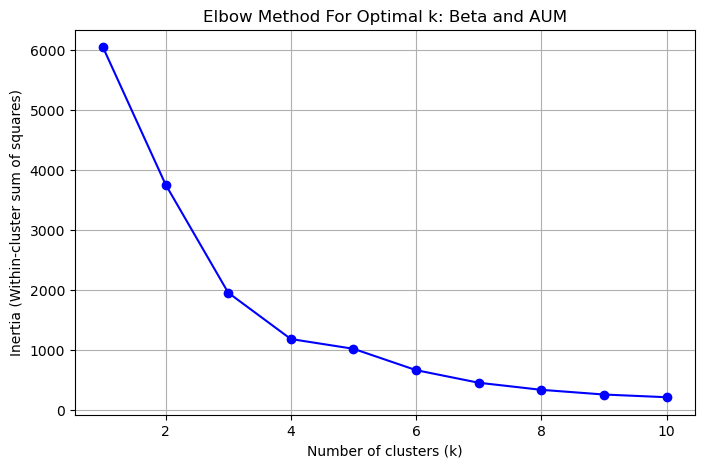

In [43]:
# 3.6 Elbow method to determine the best k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clustering_data_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method For Optimal k: Beta and AUM')
plt.grid(True)
plt.savefig("Elbow Method for Optimal K: Beta and AUM", dpi=300, bbox_inches="tight")
plt.show()

- The elbow plot is used to choose the number of clusters. Based on visual inspection, k = 4 is selected because inertia decreases sharply up to four clusters and begins to flatten after that point.

In [44]:
# 3.7 Fit K-means ( k = 4 selected because inertia decreases sharply up to four clusters and begins to flatten after that point

# Apply K-means clustering

kmeans = KMeans(n_clusters=4, random_state=42)
ticker_stats["cluster_beta_aum"] = kmeans.fit_predict(clustering_data_scaled)

print("Cluster sizes:")
print(ticker_stats["cluster_beta_aum"].value_counts().sort_index())


Cluster sizes:
cluster_beta_aum
0    2970
1       2
2       4
3      47
Name: count, dtype: int64


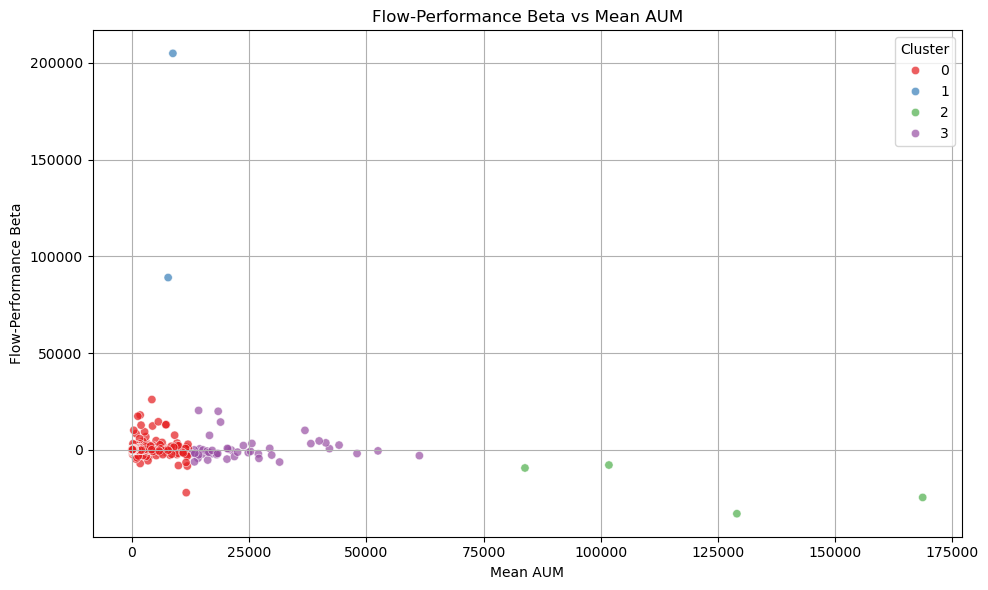

In [45]:
# 3.8 Visualize clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ticker_stats,
    x="mean_aum",
    y="beta",
    hue="cluster_beta_aum",
    palette="Set1",
    alpha=0.7
)

plt.title("Flow-Performance Beta vs Mean AUM")
plt.xlabel("Mean AUM")
plt.ylabel("Flow-Performance Beta")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# 3.9 Cluster summary

cluster_summary_1 = ticker_stats.groupby("cluster_beta_aum").agg(
    mean_beta=("beta", "mean"),
    mean_aum=("mean_aum", "mean"),
    number_of_etfs=("PERMNO", "count")
)
print("Cluster Summary 1")
print(cluster_summary_1)

Cluster Summary 1
                    mean_beta     mean_aum  number_of_etfs
cluster_beta_aum                                          
0                     71.5598     615.4458            2970
1                146,968.4207   8,206.5440               2
2                -18,779.8772 120,823.2770               4
3                    444.6174  24,155.8174              47


- Most ETFs fall into Cluster 0, which has relatively low average flow-performance beta and moderate AUM. This suggests that the majority of ETFs have fairly stable flow behaviour and are not highly sensitive to past returns.

- The smaller clusters capture ETFs with more extreme characteristics, such as very high beta, very large AUM, or negative average beta. Because the cluster sizes are uneven, the results should be interpreted as broad behavioural groups rather than perfectly balanced ETF segments.

# Q2a(ii): K-means clustering using beta and volatility

This clustering uses:

- `beta`: flow-performance sensitivity
- `vol`: ETF return volatility

In [47]:
# 3.10 Prepare the data
# Use beta and volatility for clustering

features = ["beta", "vol"]
clustering_data = ticker_stats[features].copy()


In [48]:
# 3.11 Standardize the ETF level features

scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(ticker_stats[features])

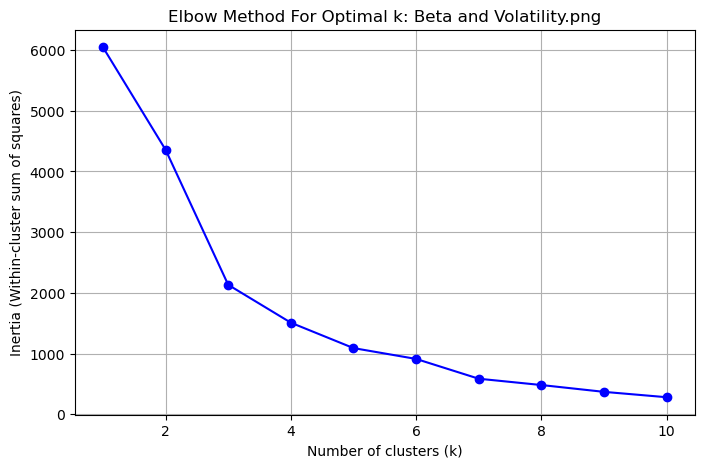

In [49]:
# 3.12 Elbow method to determine the best k

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clustering_data_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method For Optimal k: Beta and Volatility.png')
plt.grid(True)
plt.show()

- The beta-volatility elbow plot suggests k = 3 because inertia decreases sharply up to three clusters and begins to flatten after that point.

In [50]:
# 3.13 Apply K-means clustering (Based on visual inspection of the elbow plot, k = 3 is selected because the inertia decreases sharply up to three clusters and begins to flatten after that point)

kmeans = KMeans(n_clusters=3, random_state=42)
ticker_stats["cluster_beta_vol"] = kmeans.fit_predict(clustering_data_scaled)

print("Cluster sizes:")
print(ticker_stats["cluster_beta_vol"].value_counts().sort_index())

Cluster sizes:
cluster_beta_vol
0    2748
1       1
2     274
Name: count, dtype: int64


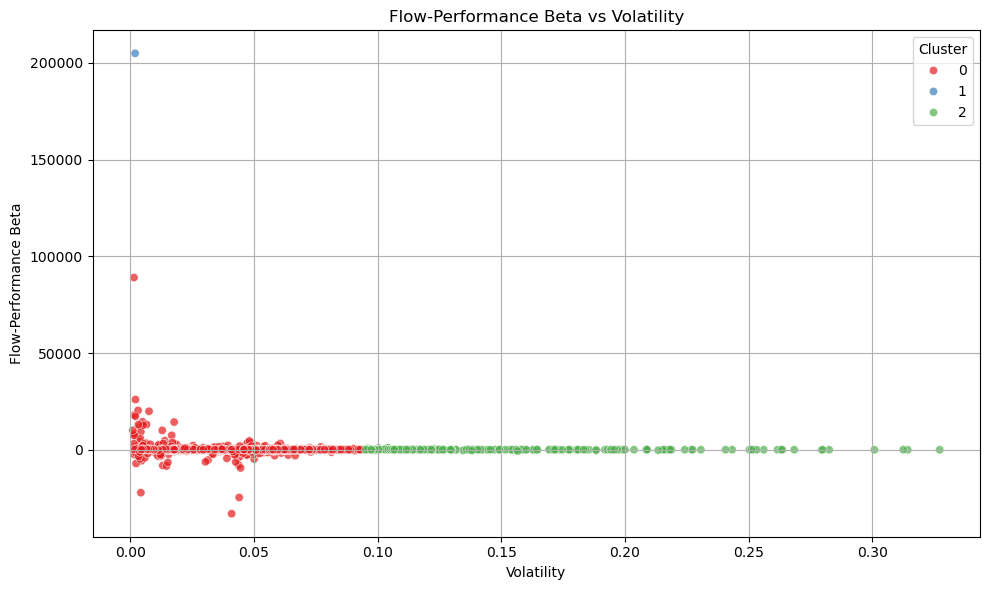

In [51]:
# 3.14 Visualize clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ticker_stats,
    x="vol",
    y="beta",
    hue="cluster_beta_vol",
    palette="Set1",
    alpha=0.7
)

plt.title("Flow-Performance Beta vs Volatility")
plt.xlabel("Volatility")
plt.ylabel("Flow-Performance Beta")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
# 3.15 Cluster summary

cluster_summary_2 = ticker_stats.groupby("cluster_beta_vol").agg(
    mean_beta=("beta", "mean"),
    mean_vol=("vol", "mean"),
    number_of_etfs=("PERMNO", "count")
)
print("Cluster summary 2")
print(cluster_summary_2)

Cluster summary 2
                    mean_beta  mean_vol  number_of_etfs
cluster_beta_vol                                       
0                     88.5421    0.0452            2748
1                204,925.2490    0.0020               1
2                     14.6279    0.1412             274


- Most ETFs fall into Cluster 0, which has low average volatility and relatively low flow-performance beta. This suggests that most ETFs have moderate flow sensitivity and lower return risk.

- Cluster 2 captures higher-volatility ETFs, while Cluster 1 appears to be an outlier with extremely high beta. The uneven cluster sizes show that k-means is influenced by extreme ETFs, so the clustering results should be interpreted cautiously and supported by the sensitivity check.

# Q2a(iii): Flow-performance sensitivity by fund type

Instead of clustering, this section compares whether average flow-performance sensitivity differs across fund types.

In [53]:
# 3.16 Compare beta by fund type

fund_type_beta = ticker_stats[ticker_stats["fund_type"] != "Other"]

fund_type_summary = fund_type_beta.groupby("fund_type").agg(
    mean_beta=("beta", "mean"),
    median_beta=("beta", "median"),
    number_of_etfs=("PERMNO", "count")
).sort_values("mean_beta", ascending=False)

print(fund_type_summary)

                    mean_beta  median_beta  number_of_etfs
fund_type                                                 
Commodity            421.8468      22.3411              37
Broad Equity         267.5029      16.1835             927
Sector Equity         16.9473      64.3723               4
International/EM      16.1128       4.7252             142
Bond/Fixed Income -1,395.8616    -720.4282               6


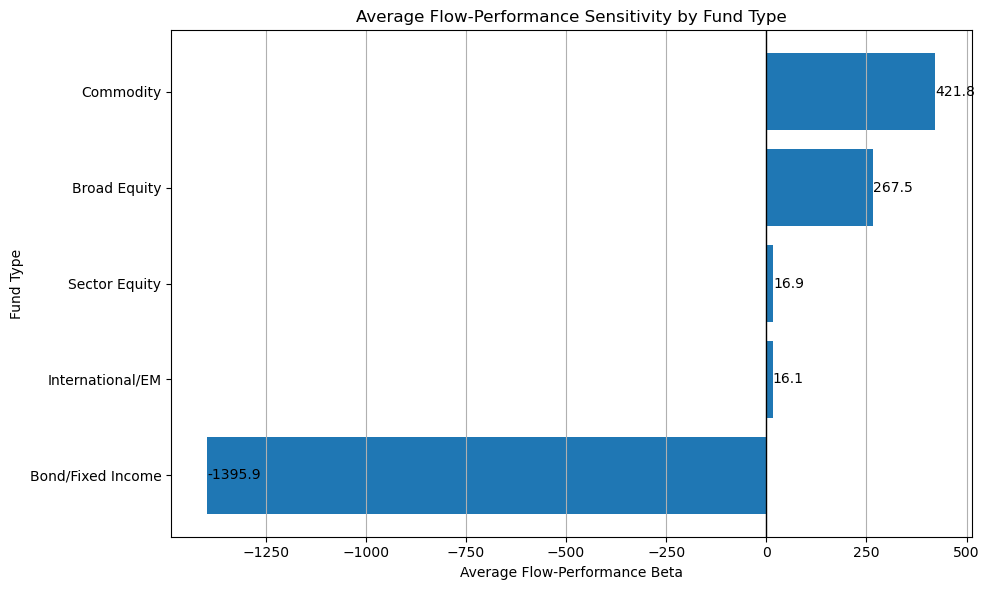

In [54]:
# 3.17 Visualize average beta by fund type

fund_type_summary_plot = fund_type_summary.sort_values("mean_beta")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    fund_type_summary_plot.index,
    fund_type_summary_plot["mean_beta"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Average Flow-Performance Beta")
plt.ylabel("Fund Type")
plt.title("Average Flow-Performance Sensitivity by Fund Type")

# Add value labels beside each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center"
    )

plt.grid(axis="x")
plt.tight_layout()
plt.savefig("Average Flow-performance Sensitivity by Fund Type.png", dpi=300, bbox_inches="tight")
plt.show()

- The chart shows that average flow-performance sensitivity differs across fund types. Commodity and broad equity ETFs show positive average beta, suggesting flows are more responsive to past returns. Bond/fixed income ETFs show a large negative average beta, so this category should be interpreted cautiously because it may be influenced by extreme observations or a small number of ETFs.

In [55]:
# 3.18 Example ETF's per cluster

for c in sorted(ticker_stats["cluster_beta_aum"].unique()):
    tickers = ticker_stats[ticker_stats["cluster_beta_aum"] == c]["TICKER"].tolist()
    print(f"\nCluster {c} ({len(tickers)} ETFs):")
    print(f"  Sample: {tickers[:10]}")


Cluster 0 (2970 ETFs):
  Sample: ['AADR', 'GRV', 'FCGS', 'FCGL', 'RETL', 'SCIN', 'LIT', 'BRAF', 'BRAQ', 'AXUT']

Cluster 1 (2 ETFs):
  Sample: ['SGOV', 'BIL']

Cluster 2 (4 ETFs):
  Sample: ['VOO', 'SPY', 'IVV', 'VTI']

Cluster 3 (47 ETFs):
  Sample: ['VXUS', 'USMV', 'SCHD', 'IXUS', 'IEFA', 'IEMG', 'BNDX', 'QUAL', 'JPST', 'RSP']


In [56]:
# 3.19 Sensitivity Check — Additional Robustness Test

#The cluster summaries show uneven cluster sizes, which suggests that extreme beta or AUM values may influence the k-means results.
#This sensitivity check removes the most extreme beta and AUM observations and repeats the beta-AUM clustering. This is included as an additional robustness check for the modelling limitations.

# Remove extreme values for sensitivity check
beta_low = ticker_stats["beta"].quantile(0.01)
beta_high = ticker_stats["beta"].quantile(0.99)
aum_high = ticker_stats["mean_aum"].quantile(0.99)

ticker_stats_sensitivity = ticker_stats[
    (ticker_stats["beta"] >= beta_low) &
    (ticker_stats["beta"] <= beta_high) &
    (ticker_stats["mean_aum"] <= aum_high)
].copy()

print("Original ETFs:", len(ticker_stats))
print("ETFs after sensitivity filter:", len(ticker_stats_sensitivity))

# Repeat for beta and AUM clustering after removing extreme values
features = ["beta", "mean_aum"]
clustering_data = ticker_stats_sensitivity[features].copy()

scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(ticker_stats_sensitivity[features])

kmeans = KMeans(n_clusters=4, random_state=42)
ticker_stats_sensitivity["cluster_beta_aum"] = kmeans.fit_predict(clustering_data_scaled)

print("Cluster sizes after sensitivity filter:")
print(ticker_stats_sensitivity["cluster_beta_aum"].value_counts().sort_index())

Original ETFs: 3023
ETFs after sensitivity filter: 2947
Cluster sizes after sensitivity filter:
cluster_beta_aum
0    2723
1     122
2      72
3      30
Name: count, dtype: int64


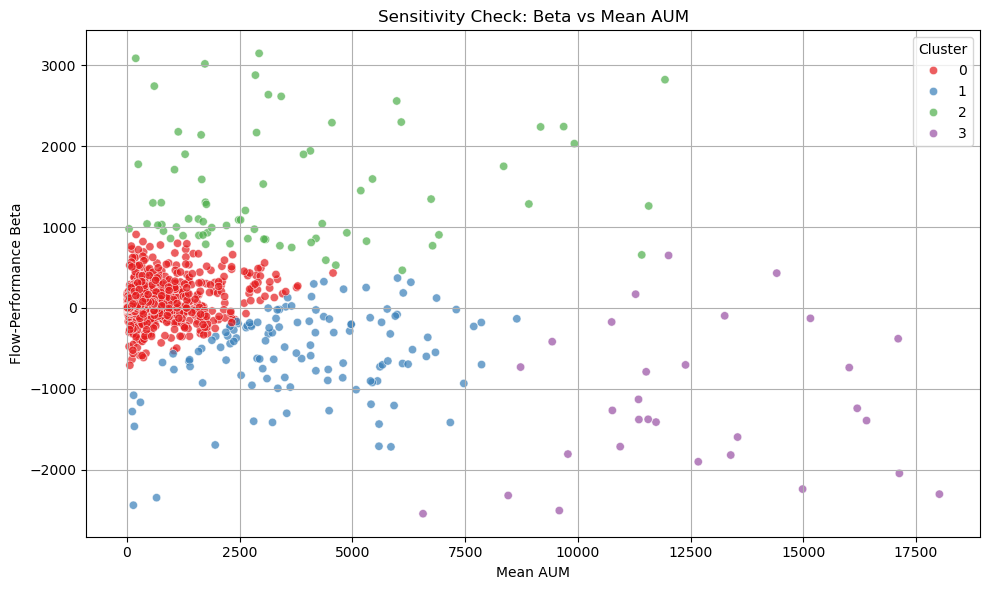

In [57]:
# Visualise the sensitivity check 

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=ticker_stats_sensitivity,
    x="mean_aum",
    y="beta",
    hue="cluster_beta_aum",
    palette="Set1",
    alpha=0.7
)

plt.title("Sensitivity Check: Beta vs Mean AUM")
plt.xlabel("Mean AUM")
plt.ylabel("Flow-Performance Beta")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.savefig("Sensitivity Check: Beta Vs Mean AUM.png", dpi=300, bbox_inches="tight")
plt.show()

- The sensitivity check shows that after removing the most extreme beta and AUM observations, the beta-AUM clusters become more interpretable. The chart still shows clear groups based on ETF size and flow-performance beta, but the extreme ETFs no longer dominate the clustering as strongly.

- This confirms that the original k-means results were partly influenced by outliers. Therefore, the main clustering results should be interpreted cautiously, while the sensitivity check supports the broader finding that ETFs differ in both fund size and flow-performance sensitivity.

# 4.0 Q3: ETF Market Beta Over time

In [58]:
# 4.1 Prepare data for market beta regression

# Keep required variables

market_data = panel[["PERMNO", "TICKER", "COMNAM", "date", "year", "RET", "sprtrn"]].dropna()

market_data.head()

,PERMNO,TICKER,COMNAM,date,year,RET,sprtrn
1,10113,AADR,ADVISORSHARES TRUST,2010-08-31,2010,0.0098,-0.0474
2,10113,AADR,ADVISORSHARES TRUST,2010-09-30,2010,0.1130,0.0876
3,10113,AADR,ADVISORSHARES TRUST,2010-10-29,2010,0.0230,0.0369
4,10113,AADR,ADVISORSHARES TRUST,2010-11-30,2010,-0.0194,-0.0023
5,10113,AADR,ADVISORSHARES TRUST,2010-12-31,2010,0.0569,0.0653


## Market-Beta Regression Specification

The market-beta regression specification is:

\[
RET_{i,t} = \alpha + \beta \, sprtrn_t + \varepsilon_{i,t}
\]

where \(RET_{i,t}\) is ETF \(i\)'s monthly return, \(sprtrn_t\) is the S&P 500 return in the same month, and \(\beta\) is the ETF's market beta. This regression is estimated separately for each ETF-year with at least 8 monthly observations.

In [59]:
# 4.2 Example market beta regression

# Select SPY as an example ETF
spy_market = market_data[market_data["TICKER"] == "SPY"]

# Estimate market beta regression
market_model = smf.ols("RET ~ sprtrn", data=spy_market).fit()

print(market_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    RET   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.234e+05
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:09:29   Log-Likelihood:                 1415.8
No. Observations:                 300   AIC:                            -2828.
Df Residuals:                     298   BIC:                            -2820.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0015      0.000     12.023      0.0

- The SPY example market-beta regression shows a coefficient on `sprtrn` of approximately 0.996. This means SPY’s monthly returns move almost one-for-one with S&P 500 returns. That is expected because SPY tracks the S&P 500 index.

- The very high R-squared also confirms that S&P 500 returns explain nearly all variation in SPY returns.

In [60]:
# 4.3 Estimate market beta for each ETF year

market_beta_results = []

for permno in market_data["PERMNO"].unique():

    df_etf = market_data[market_data["PERMNO"] == permno]

    for year in df_etf["year"].unique():

        df_year = df_etf[df_etf["year"] == year]

        if len(df_year) >= 8:

            model = smf.ols("RET ~ sprtrn", data=df_year).fit()

            market_beta_results.append({
                "PERMNO": permno,
                "TICKER": df_year["TICKER"].iloc[0],
                "COMNAM": df_year["COMNAM"].iloc[0],
                "year": year,
                "market_beta": model.params["sprtrn"],
                "observations": int(model.nobs)
            })

market_beta_data = pd.DataFrame(market_beta_results)

market_beta_data.head()

,PERMNO,TICKER,COMNAM,year,market_beta,observations
0,10113,AADR,ADVISORSHARES TRUST,2011,1.1141,12
1,10113,AADR,ADVISORSHARES TRUST,2012,0.9731,12
2,10113,AADR,ADVISORSHARES TRUST,2013,0.9789,12
3,10113,AADR,ADVISORSHARES TRUST,2014,1.0819,12
4,10113,AADR,ADVISORSHARES TRUST,2015,1.1590,12


- The ETF-year market beta table shows the estimated sensitivity of each ETF’s returns to S&P 500 returns for each year.

- For example, AADR has yearly market betas close to 1 in several years, meaning its returns moved broadly with the market during those periods. These ETF-year beta estimates are then averaged by year to analyse the overall ETF market-beta trend.

In [61]:
# 4.4 Calculate average market beta by year

yearly_market_beta = market_beta_data.groupby("year").agg(
    average_market_beta=("market_beta", "mean"),
    number_of_etfs=("PERMNO", "count")
).reset_index()

yearly_market_beta.head()


,year,average_market_beta,number_of_etfs
0,2000,0.8587,38
1,2001,1.2145,96
2,2002,1.1270,116
3,2003,1.0504,129
4,2004,1.2943,151


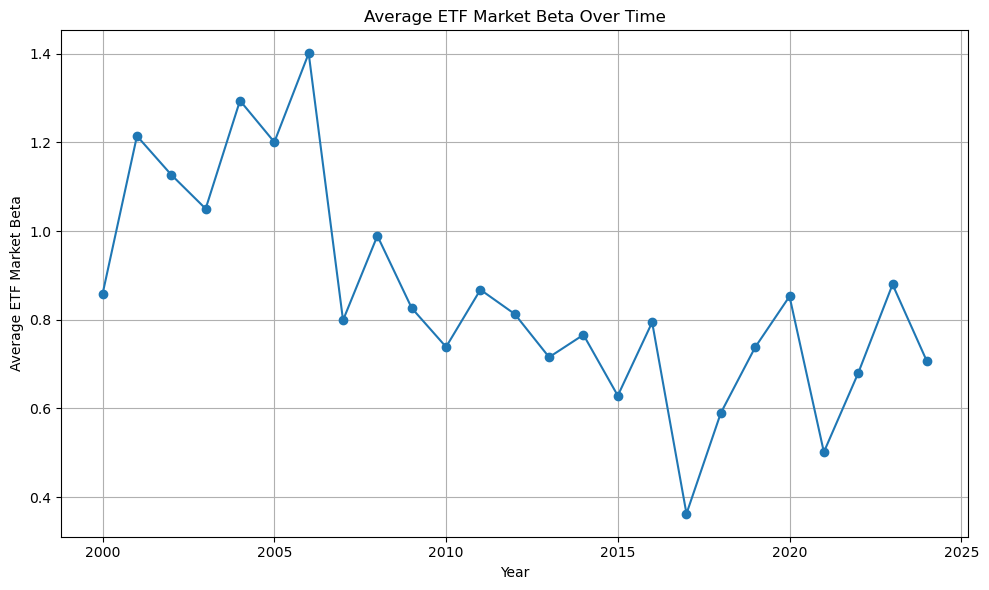

In [62]:
# 4.5 Visualise the yearly trend in average ETF market beta

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_market_beta["year"],
    yearly_market_beta["average_market_beta"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average ETF Market Beta")
plt.title("Average ETF Market Beta Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("Average ETF Market Beta Over Time.png", dpi=300, bbox_inches="tight")
plt.show()

- The average ETF market beta changes over time rather than staying constant. In the early 2000s, the average beta is generally close to or above 1, suggesting stronger market exposure.

- From the late 2000s onward, the average beta is often below 1, indicating that the ETF universe became less purely tied to S&P 500 movements. This may reflect the growth of bond, commodity, international, sector, leveraged, inverse, and other non-broad-equity ETF products.

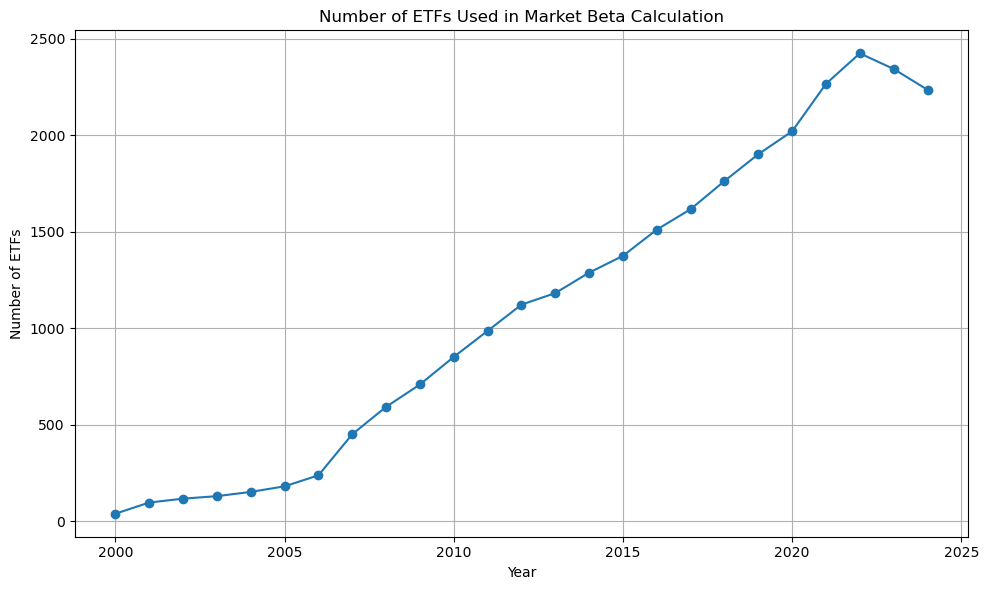

In [63]:
# 4.6 Visualise the number of ETF's included in each yearly beta estimate

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_market_beta["year"],
    yearly_market_beta["number_of_etfs"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of ETFs")
plt.title("Number of ETFs Used in Market Beta Calculation")
plt.grid(True)
plt.tight_layout()
plt.savefig("Number of ETFs Used in Market Beta Calculation.png", dpi=300, bbox_inches="tight")
plt.show()

- The number of ETFs included in the market-beta calculation increases substantially over time, rising from a small ETF universe in the early 2000s to more than 2,000 ETFs in later years.

- This means the market-beta trend should be interpreted with caution because changes in average beta may reflect changes in the composition of the ETF market, not only changes in the behaviour of existing ETFs.

# Methodological Limitations

- This analysis has several limitations. The data does not include all factors that could affect ETF flows, such as fund fees, liquidity, investor sentiment, macroeconomic conditions, product launches, and marketing activity. Consequently, past returns, lagged flows, AUM and month effects may not completely account for investor flow behaviour.

- The classification of the fund type is derived from the ETF name by keyword matching; therefore, the classification should be considered as a guideline rather than an absolute one. An ETF might be classified under a broad or mixed category where it is hard to tell the name of the ETF.

- Extreme beta, AUM and volatility values influence the clustering results. This can be seen in the uneven sizes of the clusters, with the majority of ETFs in one large cluster and a few ETFs in very small clusters. A sensitivity check is added to determine if the primary beta-AUM clustering is interpretable when the influence of extreme observations is reduced.

- Caution should be used with the market beta trend as well since the universe of ETFs evolves. There are many more ETFs, and a broader variety of product types, in the later years, so the changes in the average market beta may be due as much to changes in the composition of the market as to changes in the same funds over time.